# Spider Exploration — Week 1

Sanity-check stats on Spider train + dev and the 166 databases in `tables.json`.
Uses `src/schema_linking/data_loader.py` and `src/schema_linking/schema_parser.py`.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, "src")

import pandas as pd
import matplotlib.pyplot as plt

from schema_linking.data_loader import load_spider_questions
from schema_linking.schema_parser import load_schemas

train = load_spider_questions("train")
dev = load_spider_questions("dev")
schemas = load_schemas()

print(f"loaded {len(train)} train, {len(dev)} dev, {len(schemas)} schemas")

loaded 7000 train, 1034 dev, 166 schemas


## 1. Dataset sizes

In [2]:
pd.DataFrame(
    {"examples": [len(train), len(dev)], "unique_db_ids": [len({e.db_id for e in train}), len({e.db_id for e in dev})]},
    index=pd.Index(["train", "dev"], name="split"),
)

,examples,unique_db_ids
split,,
train,7000,140
dev,1034,20


## 2. Per-database stats

Distribution of `#tables` and `#columns` across the 166 DBs in `tables.json`.

In [3]:
db_stats = pd.DataFrame(
    [
        {
            "db_id": s.db_id,
            "n_tables": len(s.tables),
            "n_columns": sum(len(t.columns) for t in s.tables),
        }
        for s in schemas.values()
    ]
)
db_stats[["n_tables", "n_columns"]].describe().round(2)

,n_tables,n_columns
count,166.00,166.00
mean,5.28,27.13
std,3.87,30.80
min,2.00,6.00
25%,3.00,13.00
50%,4.00,19.50
75%,7.00,30.75
max,26.00,352.00


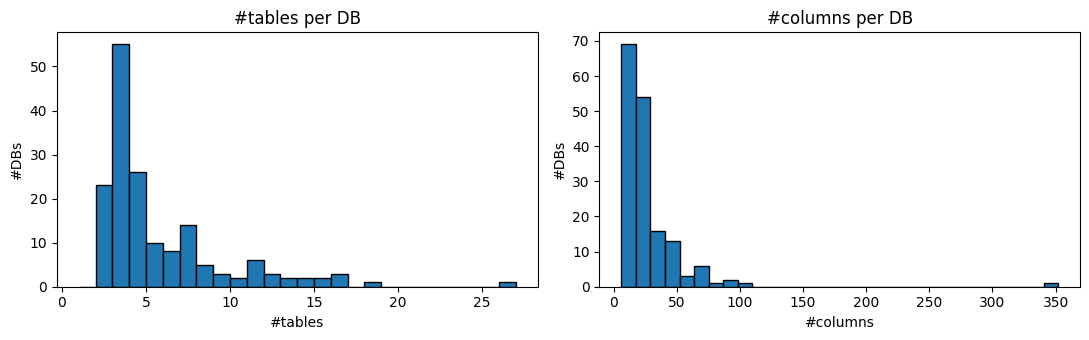

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(db_stats["n_tables"], bins=range(1, db_stats["n_tables"].max() + 2), edgecolor="black")
axes[0].set_title("#tables per DB")
axes[0].set_xlabel("#tables"); axes[0].set_ylabel("#DBs")

axes[1].hist(db_stats["n_columns"], bins=30, edgecolor="black")
axes[1].set_title("#columns per DB")
axes[1].set_xlabel("#columns"); axes[1].set_ylabel("#DBs")

plt.tight_layout()
plt.show()

In [5]:
print("Smallest 5 DBs by #tables:")
print(db_stats.nsmallest(5, "n_tables").to_string(index=False))
print("\nLargest 5 DBs by #columns:")
print(db_stats.nlargest(5, "n_columns").to_string(index=False))

Smallest 5 DBs by #tables:
        db_id  n_tables  n_columns
  perpetrator         2         13
 body_builder         2         11
   race_track         2         10
manufactory_1         2          9
    network_2         2          8

Largest 5 DBs by #columns:
                    db_id  n_tables  n_columns
               baseball_1        26        352
cre_Drama_Workshop_Groups        18         99
                formula_1        13         94
                 sakila_1        16         89
                 soccer_1         7         86


## 3. Question length distribution

Words and characters, train vs dev side by side.

In [6]:
def lengths(examples):
    return pd.DataFrame(
        {
            "n_words": [len(e.question.split()) for e in examples],
            "n_chars": [len(e.question) for e in examples],
        }
    )

train_len = lengths(train)
dev_len = lengths(dev)

pd.concat({"train": train_len.describe(), "dev": dev_len.describe()}, axis=1).round(2)

train               dev         
       n_words  n_chars  n_words  n_chars
count  7000.00  7000.00  1034.00  1034.00
mean     12.72    70.86    12.43    68.05
std       4.34    23.89     4.28    22.72
min       3.00    16.00     4.00    18.00
25%      10.00    54.00     9.00    52.00
50%      12.00    69.00    12.00    66.00
75%      15.00    86.00    15.00    81.75
max      39.00   224.00    28.00   174.00

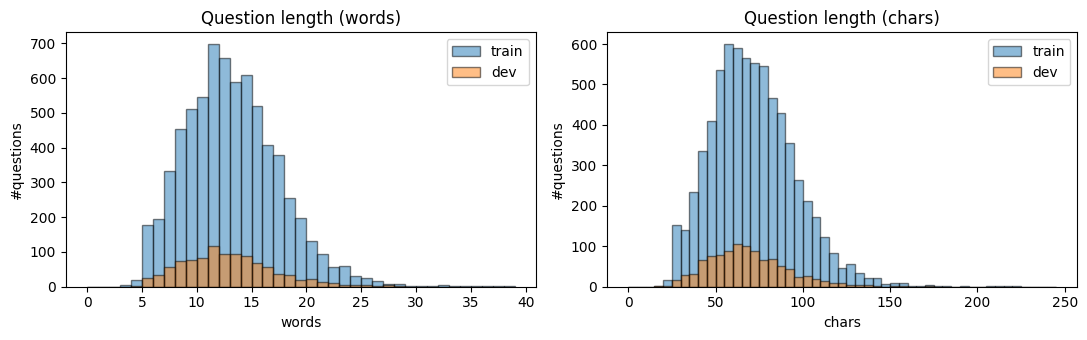

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for split_name, df in [("train", train_len), ("dev", dev_len)]:
    axes[0].hist(df["n_words"], bins=range(0, 40), alpha=0.5, label=split_name, edgecolor="black")
    axes[1].hist(df["n_chars"], bins=range(0, 250, 5), alpha=0.5, label=split_name, edgecolor="black")

axes[0].set_title("Question length (words)"); axes[0].set_xlabel("words"); axes[0].set_ylabel("#questions"); axes[0].legend()
axes[1].set_title("Question length (chars)"); axes[1].set_xlabel("chars"); axes[1].set_ylabel("#questions"); axes[1].legend()

plt.tight_layout()
plt.show()

## 4. SQL hardness distribution

Spider's parsed `sql` dict on each example carries structural info
(`select`, `from`, `where`, `groupBy`, `having`, `orderBy`, `limit`,
`union`, `intersect`, `except`) but **does not** include a pre-computed
`difficulty` / `hardness` label. Hardness in the Spider benchmark is
derived by their eval script from the parsed-SQL shape (counts of WHERE
/ GROUP BY clauses, aggregates, nestings, set operations).


In [8]:
def has_clause(ex, key):
    val = ex.sql.get(key)
    if isinstance(val, (list, dict)):
        return bool(val)
    return val is not None

clause_keys = ["where", "groupBy", "having", "orderBy", "limit", "union", "intersect", "except"]

clause_counts = pd.DataFrame(
    {
        "train": {k: sum(has_clause(e, k) for e in train) for k in clause_keys},
        "dev":   {k: sum(has_clause(e, k) for e in dev)   for k in clause_keys},
    }
)
clause_counts["train_pct"] = (100 * clause_counts["train"] / len(train)).round(1)
clause_counts["dev_pct"]   = (100 * clause_counts["dev"]   / len(dev)).round(1)
clause_counts

,train,dev,train_pct,dev_pct
where,3409,478,48.7,46.2
groupBy,1731,271,24.7,26.2
having,409,75,5.8,7.3
orderBy,1594,231,22.8,22.3
limit,1073,183,15.3,17.7
union,65,9,0.9,0.9
intersect,240,38,3.4,3.7
except,205,29,2.9,2.8


## 6. Worked example — `concert_singer`

Full schema (tables, columns, types, PK flag, FK pairs) plus three sample question/SQL pairs.

In [9]:
cs = schemas["concert_singer"]
print(f"db_id: {cs.db_id}")
print(f"tables: {len(cs.tables)}\n")
for t in cs.tables:
    print(f"  {t.original_name}  ({t.name})")
    for c in t.columns:
        pk = "  [PK]" if c.is_primary_key else ""
        print(f"    - {c.original_name}: {c.type}{pk}")
print(f"\nforeign keys ({len(cs.foreign_keys)}) — raw Spider column indices:")
for fk in cs.foreign_keys:
    print(f"  col_idx {fk.from_col_idx} -> col_idx {fk.to_col_idx}")

db_id: concert_singer
tables: 4

  stadium  (stadium)
    - Stadium_ID: number  [PK]
    - Location: text
    - Name: text
    - Capacity: number
    - Highest: number
    - Lowest: number
    - Average: number
  singer  (singer)
    - Singer_ID: number  [PK]
    - Name: text
    - Country: text
    - Song_Name: text
    - Song_release_year: text
    - Age: number
    - Is_male: others
  concert  (concert)
    - concert_ID: number  [PK]
    - concert_Name: text
    - Theme: text
    - Stadium_ID: text
    - Year: text
  singer_in_concert  (singer in concert)
    - concert_ID: number  [PK]
    - Singer_ID: text

foreign keys (3) — raw Spider column indices:
  col_idx 18 -> col_idx 1
  col_idx 21 -> col_idx 8
  col_idx 20 -> col_idx 15


In [10]:
cs_examples = [e for e in (*train, *dev) if e.db_id == "concert_singer"][:3]
for i, ex in enumerate(cs_examples, 1):
    print(f"[{i}] Q: {ex.question}")
    print(f"    SQL: {ex.query}\n")

[1] Q: How many singers do we have?
    SQL: SELECT count(*) FROM singer

[2] Q: What is the total number of singers?
    SQL: SELECT count(*) FROM singer

[3] Q: Show name, country, age for all singers ordered by age from the oldest to the youngest.
    SQL: SELECT name ,  country ,  age FROM singer ORDER BY age DESC

